In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import stan

import nest_asyncio
nest_asyncio.apply()

import logging
logging.getLogger().setLevel(logging.ERROR)

ModuleNotFoundError: No module named 'stan'

In [2]:
## Output folder for figures
out_dir = Path("output")
out_dir.mkdir(exist_ok=True)

In [3]:
## Load stability and nnd metrics
df = pd.read_csv('processed_data/stability_ALL.csv', parse_dates=['date_now', 'date_prev'])
df2 = pd.read_csv('processed_data/nnd_ALL.csv')

## Factor ordering + labels
lek_order = ['Velavadar_LEK1', 'Velavadar_LEK2', 'TalChhapar_TC']
lek_labels = {'Velavadar_LEK1': 'Velavadar Lek 1','Velavadar_LEK2': 'Velavadar Lek 2','TalChhapar_TC': 'Tal Chhapar'}

df['lek_id'] = (pd.Categorical(df['lek_id'],categories=lek_order,ordered=True).rename_categories(lek_labels))
df2['lek_id'] = (pd.Categorical(df2['lek_id'],categories=lek_order,ordered=True).rename_categories(lek_labels))

In [4]:
## Colour palettes
fill_cols = {'Tal Chhapar': '#B5542D', 'Velavadar Lek 1': '#1F6F8B', 'Velavadar Lek 2': '#3FA7A3'}
point_cols = {'Tal Chhapar': '#D97A52', 'Velavadar Lek 1': '#15556B', 'Velavadar Lek 2': '#2B7E7B'}

lek_labels = df['lek_id'].cat.categories.tolist()

In [5]:
df2['date'] = pd.to_datetime(df2['date'])
df2 = df2[['lek_id', 'date', 'nnd_count']].dropna().copy()

df = df[['lek_id', 'date_now', 'mode_shift']].dropna().copy()
df = df.sort_values(['lek_id', 'date_now']).reset_index(drop=True)

## Serialise and centre the date / time
t0 = df['date_now'].min()
df['t_years'] = (df['date_now'] - t0).dt.days / 365.25
df['t_centred'] = df['t_years'] - df['t_years'].mean()
df2['t_years'] = (df2['date'] - t0).dt.days / 365.25
df2['t_centred'] = df2['t_years'] - df2['t_years'].mean()

## Log transform nnd columns to construct a log-normal model
df['log_mode_shift'] = np.log(df['mode_shift'].astype(float))

## Encode lek ID in a numerical variable
lek_levels = sorted(df['lek_id'].unique())
lek_map = {lek: i + 1 for i, lek in enumerate(lek_levels)}
df['site_id'] = df['lek_id'].map(lek_map).astype(int)

In [6]:
## Specify time axis
t_min, t_max = float(df['t_centred'].min()), float(df['t_centred'].max())
t_grid = np.linspace(t_min, t_max, 200)
t_years = t_grid + df['t_years'].mean()
date_grid = t0 + pd.to_timedelta(t_years * 365.25, unit='D')

In [7]:
## 1) Total effect of time on the median NND (per site)
shift_mod = """
data {
  int<lower=1> n_points;
  int<lower=1> n_sites;
  
  array[n_points] int<lower=1,upper=n_sites> site_id;
  
  vector[n_points] t;
  vector[n_points] y;
}

parameters {
  real mu_alpha;
  real mu_beta;

  vector[n_sites] alpha_raw;
  vector[n_sites] beta_raw;

  real<lower=0> tau_alpha;
  real<lower=0> tau_beta;

  real<lower=0> sigma;
}

transformed parameters {
  vector[n_sites] alpha = mu_alpha + tau_alpha * alpha_raw;
  vector[n_sites] beta  = mu_beta + tau_beta  * beta_raw;
}

model {
  mu_alpha ~ normal(0, 1);
  mu_beta ~ normal(0, 1);

  alpha_raw ~ normal(0, 1);
  beta_raw ~ normal(0, 1);

  tau_alpha ~ exponential(1);
  tau_beta ~ exponential(1);
  sigma ~ exponential(1);

  for (n in 1:n_points) {
    y[n] ~ normal(alpha[site_id[n]] + beta[site_id[n]] * t[n], sigma);
  }
}
"""

In [8]:
shift_data = {
    'n_points': len(df),
    'n_sites': int(df['site_id'].nunique()),
    'site_id': df['site_id'].astype(int).to_numpy(),
    't': df['t_centred'].astype(float).to_numpy(),
    'y': df['log_mode_shift'].astype(float).to_numpy()
}

posterior = stan.build(shift_mod, data=shift_data)
fit = posterior.sample(num_chains=4, num_warmup=1000, num_samples=1000)

Building: found in cache, done.
Sampling:   0%
Sampling:   5% (400/8000)
Sampling:  15% (1200/8000)
Sampling:  40% (3200/8000)
Sampling:  65% (5200/8000)
Sampling:  85% (6800/8000)
Sampling: 100% (8000/8000)
Sampling: 100% (8000/8000), done.
Messages received during sampling:
  Gradient evaluation took 5.6e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.56 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 4.6e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.46 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 4e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.4 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 6.2e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.62 seconds.
  Adjust your expectations accordingly!
  Informational Message: The current Metropolis proposal is ab

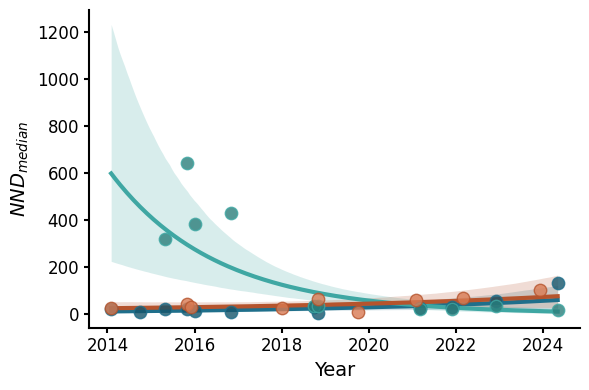

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))

for lek in lek_labels:
    df_lek = df[df['lek_id'] == lek].copy()
    site_id = np.unique(df_lek['site_id'] - 1)[0]

    # Compute posterior mean log(NND_median) and back-transform to return to original units 
    mu = fit['alpha'][site_id,:].reshape(-1,1) + fit['beta'][site_id,:].reshape(-1,1) * t_grid[None,:]
    y = np.exp(mu)
    y_mean = np.mean(y, axis=0)
    y_lower,y_upper = np.quantile(y, [0.025,0.975], axis=0)

    # Plot model fits
    ax.plot(date_grid, y_mean, linewidth=3, color=fill_cols.get(lek), label=str(lek))
    ax.fill_between(date_grid, y_lower, y_upper, color=fill_cols.get(lek), alpha=0.2, linewidth=0)

    # Add scatter to the plot
    ax.scatter(df_lek['date_now'], df_lek['mode_shift'], s=80, color=point_cols.get(lek), edgecolor=fill_cols.get(lek), alpha=0.8, zorder=4)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)

    ax.set_xlabel('Year', fontsize=14)
    ax.set_ylabel('$NND_{median}$', fontsize=14)

    plt.tight_layout()
# plt.savefig(out_dir/'mod_nnd_median.png', dpi=300, bbox_inches='tight')